In [ ]:
#################################################################
### Fig 5. Taylor Diagrams                                    ###
#################################################################

import pandas as pd
import matplotlib.pyplot as plt  
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
#import matplotlib.markers as markers
import matplotlib.patches as mpatches
import numpy as np               
import geocat.viz as gv
from numpy import array

In [12]:
### Calculate normalized standard deviation & correlation coefficient 
### for all models, precipitaiton (total) and temperature (avg),
### all seasons & monsoon
### four scales: spatially explicit daily, spatially explicit monthly, 
### spatially explicit annual & time-mean at each of 281 grids


### precipitation, all season
model_var = ['APHRO', 'ERA-I', 
             'HIRHAM (EAS)', 'HadRM3P (EAS)', 'RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)','ERA5', 'CRU','GPCC', 'CCLM (EAS)']

### precipitation, daily
df = pd.read_csv('../Data/precipitation_daily_1990-2007_ERA5.csv', index_col=0)
df_day_cord_JJASO_preci = df.loc[(df['Month'] > 5) & (df['Month'] < 11)]

target_col = 'APHRO'
feature_cols = ['ERA-I', 'HIRHAM (EAS)', 'HadRM3P (EAS)','RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)', 'ERA5']

target = df[target_col]
selected_cols = df[feature_cols]
correlation_d = selected_cols.corrwith(target, method='pearson')
sdev_d = selected_cols.std()/target.std()

# Create a new Series with two NaN values
nans_to_add = pd.Series([np.nan, np.nan])

# Concatenate them together
correlation_d  = pd.concat([correlation_d, nans_to_add], ignore_index=True)
sdev_d  = pd.concat([sdev_d, nans_to_add], ignore_index=True)

### precipitation, monthly total
df = pd.read_csv('../Data/precipitation_monthly_1990-2007_ERA5_CRU_GPCC.csv', index_col=0)
df_mon_cord_JJASO_preci = df.loc[(df['Month'] > 5) & (df['Month'] < 11)]

feature_cols = ['ERA-I', 'HIRHAM (EAS)', 'HadRM3P (EAS)','RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)', 'ERA5', 'CRU','GPCC']

target = df[target_col]
selected_cols = df[feature_cols]
correlation_m = selected_cols.corrwith(target, method='pearson')
sdev_m = selected_cols.std()/target.std()

### calculate annual precipitation (mm/mon) at each grid
group_var = ['Year','Coord']
df_yr_cord_preci = df.groupby(group_var)[model_var].mean()
df_yr_cord_preci = df_yr_cord_preci.reset_index()

target = df_yr_cord_preci[target_col]
selected_cols = df_yr_cord_preci[feature_cols]
correlation_y = selected_cols.corrwith(target, method='pearson')
sdev_y = selected_cols.std()/target.std()

### calculate avg precipitation (mm/mon) at each grid
group_var = ['Coord']
df_cord_preci = df.groupby(group_var)[model_var].mean()
df_cord_preci = df_cord_preci.reset_index()

target = df_cord_preci[target_col]
selected_cols = df_cord_preci[feature_cols]
correlation_c = selected_cols.corrwith(target, method='pearson')
sdev_c = selected_cols.std()/target.std()

a_ccorr = np.stack([correlation_c, correlation_y, correlation_m, correlation_d], axis=0)
a_sdev = np.stack([sdev_c, sdev_y, sdev_m, sdev_d], axis=0)

# Precipitation, monsoon season (Jun-Oct)
### precipitation, daily
target_col = 'APHRO'
feature_cols = ['ERA-I', 'HIRHAM (EAS)', 'HadRM3P (EAS)','RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)', 'ERA5']

target = df_day_cord_JJASO_preci[target_col]
selected_cols = df_day_cord_JJASO_preci[feature_cols]
correlation_d = selected_cols.corrwith(target, method='pearson')
sdev_d = selected_cols.std()/target.std()

# Create a new Series with two NaN values
nans_to_add = pd.Series([np.nan, np.nan])

# Concatenate them together
correlation_d  = pd.concat([correlation_d, nans_to_add], ignore_index=True)
sdev_d  = pd.concat([sdev_d, nans_to_add], ignore_index=True)

### precipitation, monthly total
#df = pd.read_csv('../Data/precipitation_monthly_1990-2007_ERA5_CRU_GPCC.csv', index_col=0)

feature_cols = ['ERA-I', 'HIRHAM (EAS)', 'HadRM3P (EAS)','RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)', 'ERA5', 'CRU','GPCC']

target = df_mon_cord_JJASO_preci[target_col]
selected_cols = df_mon_cord_JJASO_preci[feature_cols]
correlation_m = selected_cols.corrwith(target, method='pearson')
sdev_m = selected_cols.std()/target.std()

### calculate annual precipitation (mm/mon) at each grid
group_var = ['Year','Coord']
df_yr_cord_preci = df_mon_cord_JJASO_preci.groupby(group_var)[model_var].mean()
df_yr_cord_preci = df_yr_cord_preci.reset_index()

target = df_yr_cord_preci[target_col]
selected_cols = df_yr_cord_preci[feature_cols]
correlation_y = selected_cols.corrwith(target, method='pearson')
sdev_y = selected_cols.std()/target.std()

### calculate avg precipitation (mm/mon) at each grid
group_var = ['Coord']
df_cord_preci =  df_mon_cord_JJASO_preci.groupby(group_var)[model_var].mean()
df_cord_preci = df_cord_preci.reset_index()

target = df_cord_preci[target_col]
selected_cols = df_cord_preci[feature_cols]
correlation_c = selected_cols.corrwith(target, method='pearson')
sdev_c = selected_cols.std()/target.std()

b_ccorr = np.stack([correlation_c, correlation_y, correlation_m, correlation_d], axis=0)
b_sdev = np.stack([sdev_c, sdev_y, sdev_m, sdev_d], axis=0)

### Temperature, all seasons
model_var = ['APHRO', 'ERA-I', 
             'HIRHAM (EAS)', 'HadRM3P (EAS)', 'RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)','CCLM (EAS)']

### Temperature, daily
df = pd.read_csv('../Data/temperature_avg_daily_1990-2007.csv', index_col=0)
df_day_cord_JJASO_temp = df.loc[(df['Month'] > 5) & (df['Month'] < 11)]

target_col = 'APHRO'
feature_cols = ['ERA-I','CCLM (EAS)', 'HIRHAM (EAS)', 'HadRM3P (EAS)','RegCM4-1 (WAS)', #'RegCM4-4 (WAS)', 
                'HadRM3P (WAS)', 'RCA4 (WAS)']

target = df[target_col]
selected_cols = df[feature_cols]
correlation_d = selected_cols.corrwith(target, method='pearson')
sdev_d = selected_cols.std()/target.std()

### Temperature, monthly
### create monthly mean temperature at each grid
group_var = ['Year','Month','Coord']
df_mon_cord_temp = df.groupby(group_var)[model_var].mean()
df_mon_cord__temp = df_mon_cord_temp.reset_index()

#feature_cols = ['ERA-I', 'HIRHAM (EAS)', 'HadRM3P (EAS)','RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)', 'ERA5', 'CRU','GPCC']

target = df_mon_cord_temp[target_col]
selected_cols = df_mon_cord_temp[feature_cols]
correlation_m = selected_cols.corrwith(target, method='pearson')
sdev_m = selected_cols.std()/target.std()

### calculate annual temperature at each grid
group_var = ['Year','Coord']
df_yr_cord_temp = df.groupby(group_var)[model_var].mean()
df_yr_cord_temp = df_yr_cord_temp.reset_index()

target = df_yr_cord_temp [target_col]
selected_cols = df_yr_cord_temp [feature_cols]
correlation_y = selected_cols.corrwith(target, method='pearson')
sdev_y = selected_cols.std()/target.std()

### calculate avg temperature at each grid
group_var = ['Coord']
df_cord_temp = df.groupby(group_var)[model_var].mean()
df_cord_temp = df_cord_temp.reset_index()

target = df_cord_temp[target_col]
selected_cols = df_cord_temp[feature_cols]
correlation_c = selected_cols.corrwith(target, method='pearson')
sdev_c = selected_cols.std()/target.std()

c_ccorr = np.stack([correlation_c, correlation_y, correlation_m, correlation_d], axis=0)
c_sdev = np.stack([sdev_c, sdev_y, sdev_m, sdev_d], axis=0)

### Temperature Monsoon
### Temperature, daily
#df = pd.read_csv('../Data/temperature_avg_daily_1990-2007.csv', index_col=0)
#df_day_cord_JJASO_temp = df.loc[(df['Month'] > 5) & (df['Month'] < 11)]

#target_col = 'APHRO'
#feature_cols = ['ERA-I','CCLM (EAS)', 'HIRHAM (EAS)', 'HadRM3P (EAS)','RegCM4-1 (WAS)', #'RegCM4-4 (WAS)', 
#                'HadRM3P (WAS)', 'RCA4 (WAS)']

target = df_day_cord_JJASO_temp[target_col]
selected_cols = df_day_cord_JJASO_temp[feature_cols]
correlation_d = selected_cols.corrwith(target, method='pearson')
sdev_d = selected_cols.std()/target.std()

### Temperature, monthly
### create monthly mean temperature at each grid
group_var = ['Year','Month','Coord']
df_mon_cord_temp = df_day_cord_JJASO_temp.groupby(group_var)[model_var].mean()
df_mon_cord__temp = df_mon_cord_temp.reset_index()

#feature_cols = ['ERA-I', 'HIRHAM (EAS)', 'HadRM3P (EAS)','RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)', 'ERA5', 'CRU','GPCC']

target = df_mon_cord_temp[target_col]
selected_cols = df_mon_cord_temp[feature_cols]
correlation_m = selected_cols.corrwith(target, method='pearson')
sdev_m = selected_cols.std()/target.std()

### calculate annual temperature at each grid
group_var = ['Year','Coord']
df_yr_cord_temp = df_day_cord_JJASO_temp.groupby(group_var)[model_var].mean()
df_yr_cord_temp = df_yr_cord_temp.reset_index()

target = df_yr_cord_temp [target_col]
selected_cols = df_yr_cord_temp [feature_cols]
correlation_y = selected_cols.corrwith(target, method='pearson')
sdev_y = selected_cols.std()/target.std()

### calculate avg temperature at each grid
group_var = ['Coord']
df_cord_temp = df_day_cord_JJASO_temp.groupby(group_var)[model_var].mean()
df_cord_temp = df_cord_temp.reset_index()

target = df_cord_temp[target_col]
selected_cols = df_cord_temp[feature_cols]
correlation_c = selected_cols.corrwith(target, method='pearson')
sdev_c = selected_cols.std()/target.std()

d_ccorr = np.stack([correlation_c, correlation_y, correlation_m, correlation_d], axis=0)
d_sdev = np.stack([sdev_c, sdev_y, sdev_m, sdev_d], axis=0)

In [ ]:
# Variable List
var_list = ['ERA-I', 'CCLM (EAS)', 'HIRHAM (EAS)', 'HadRM3P (EAS)', 'RegCM4-1 (WAS)', 'RegCM4-4 (WAS)', 'HadRM3P (WAS)', 'RCA4 (WAS)', 'ERA5', 'CRU', 'GPCC']
colors =  ["grey", "blueviolet", "red", "blue", "lawngreen", "sienna", "orange", "cyan", "black", "olive", "indigo"]  #magenta
maintitles = ["Time-mean","Annually", "Monthly", "Daily"]

std_list = array([0., 0.5, 1.,1.5, 2., 2.5, 3.])

# Customize legend
legHande0 = mpatches.Patch(color=colors[0], label=var_list[0])
legHandel = mpatches.Patch(color=colors[1], label=var_list[1])
legHande2 = mpatches.Patch(color=colors[2], label=var_list[2])
legHande3 = mpatches.Patch(color=colors[3], label=var_list[3])
legHande4 = mpatches.Patch(color=colors[4], label=var_list[4])
legHande5 = mpatches.Patch(color=colors[5], label=var_list[5])
legHande6 = mpatches.Patch(color=colors[6], label=var_list[6])
legHande7 = mpatches.Patch(color=colors[7], label=var_list[7])
legHande8 = mpatches.Patch(color=colors[8], label=var_list[8])
legHande9 = mpatches.Patch(color=colors[9], label=var_list[9])
legHande10 = mpatches.Patch(color=colors[10], label=var_list[10])

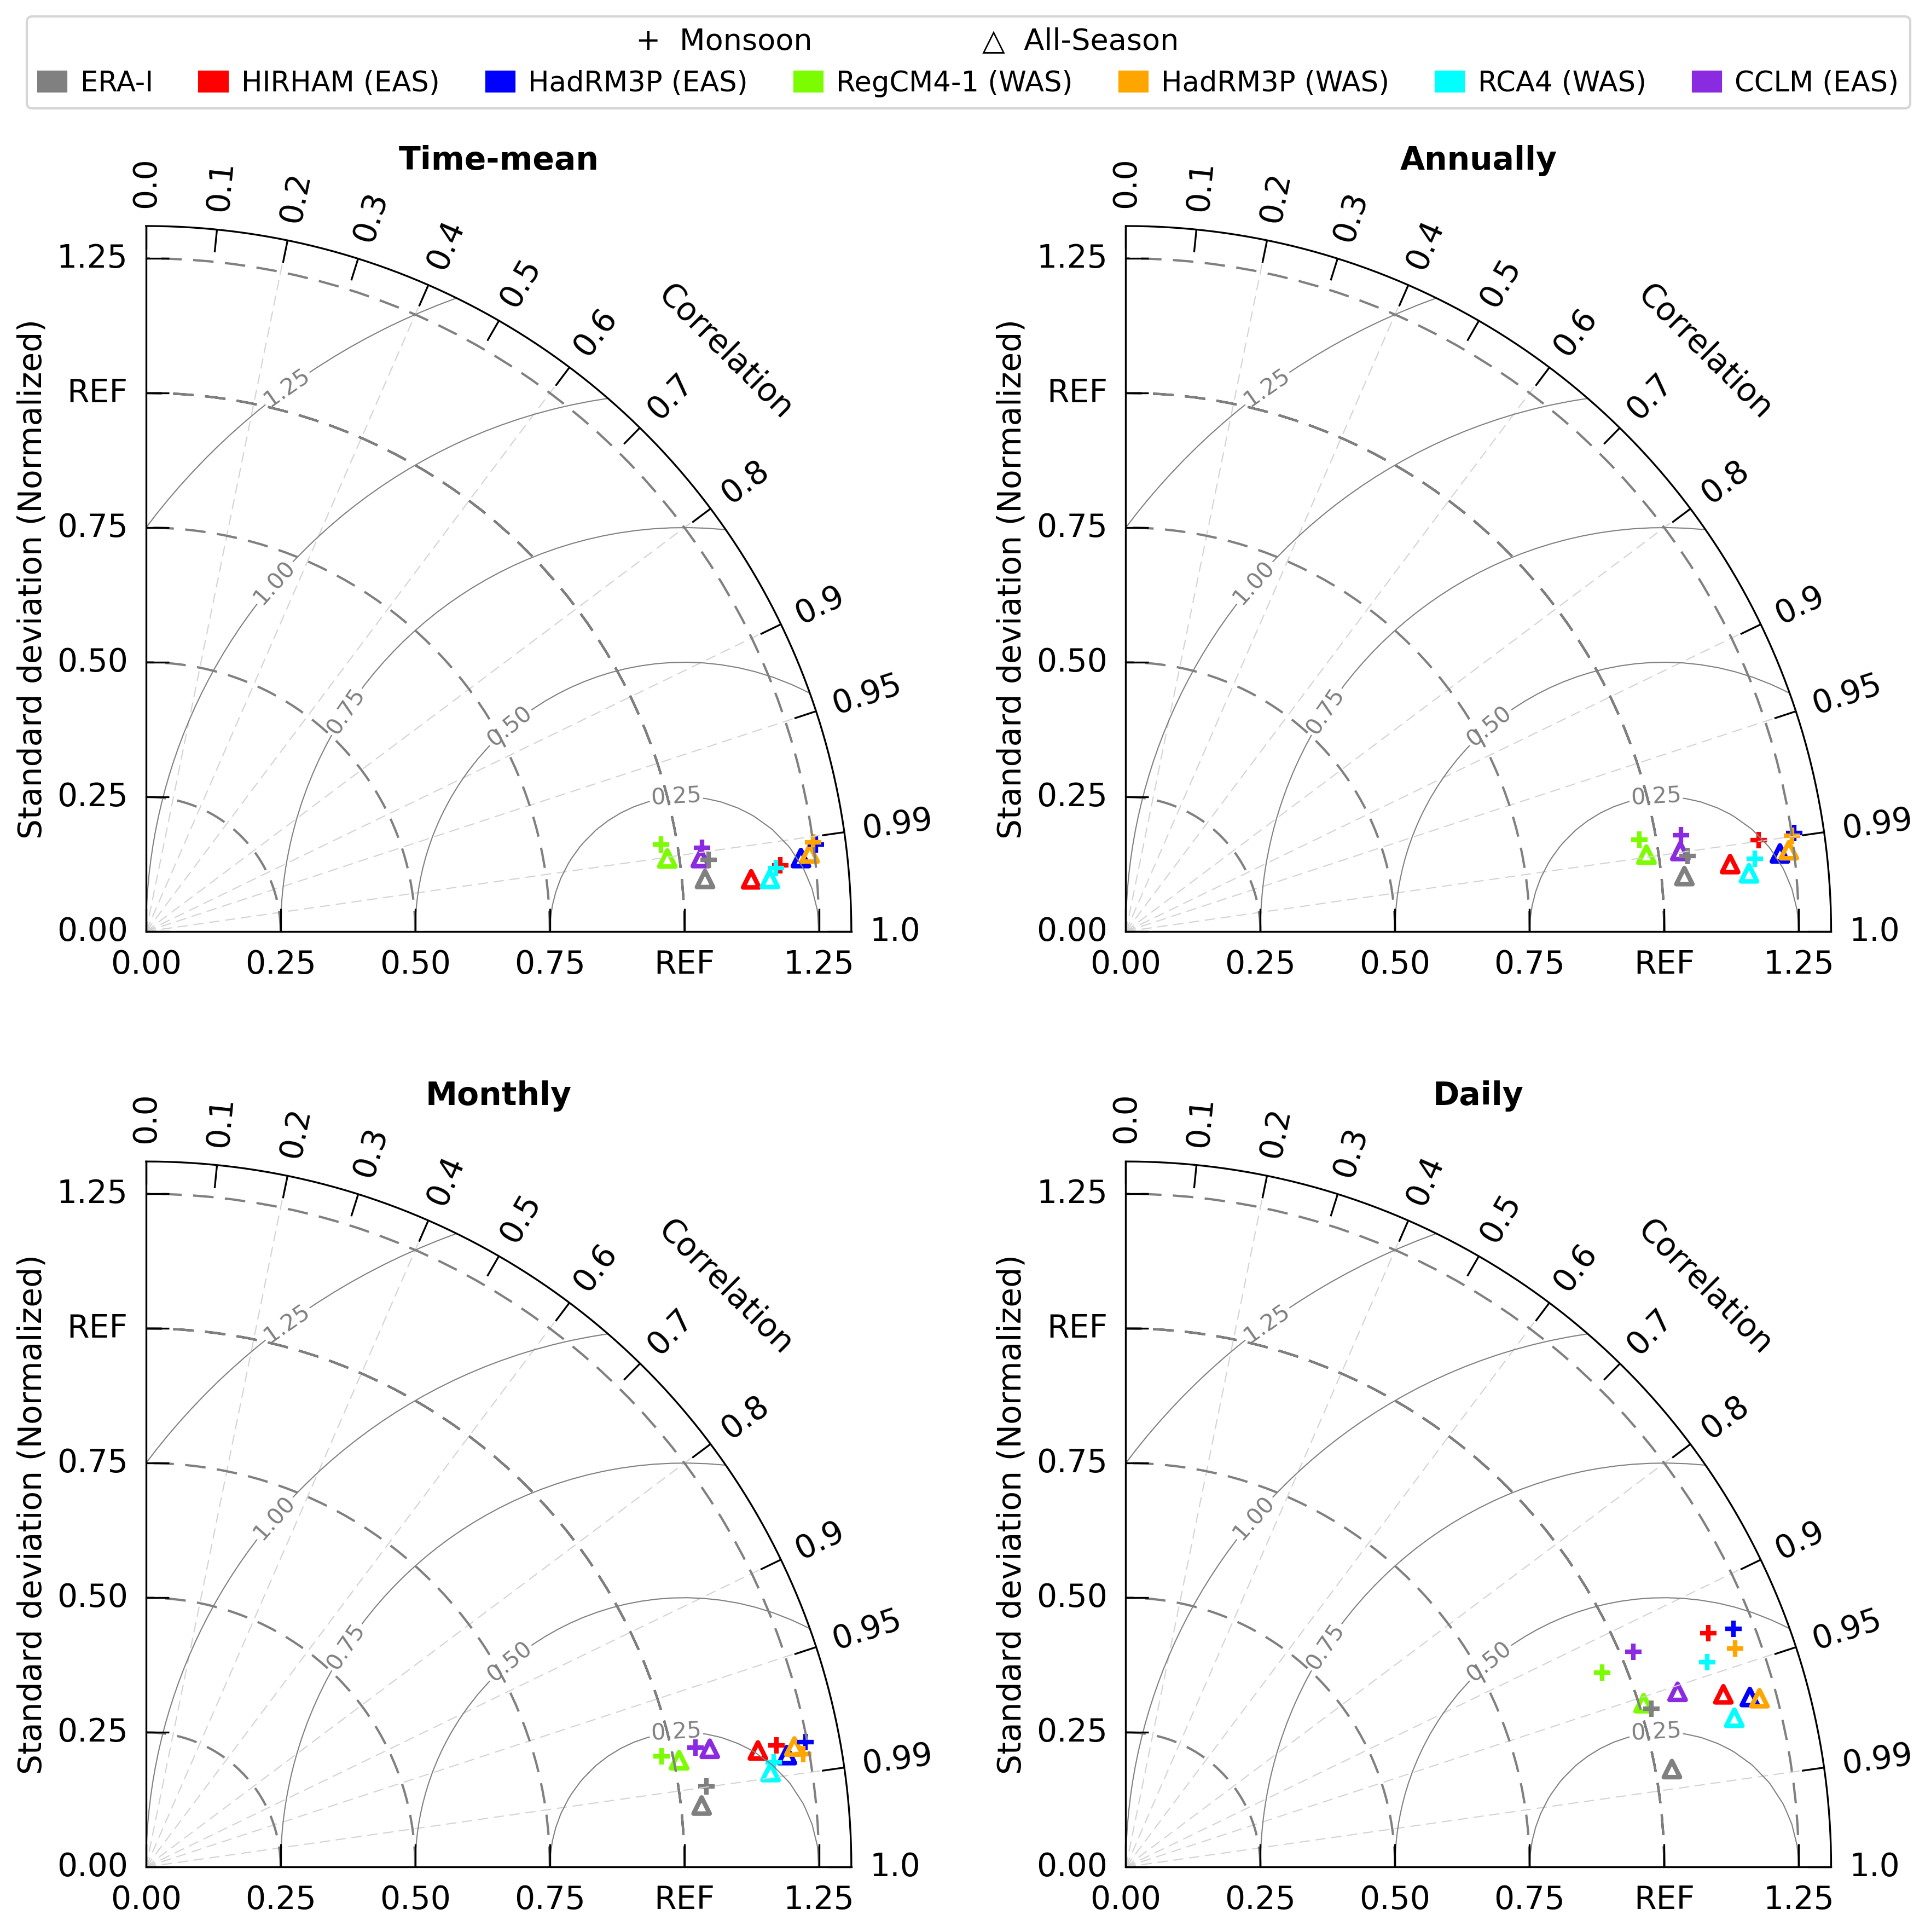

In [ ]:
# Taylor Diagram for Temperature (all-season & monsoon)
fig = plt.figure(figsize=(12, 12))

fig.subplots_adjust(wspace=0.3, hspace=0.3, left=0.07, right=0.95, bottom=0.04)

std_list_temp = array([0., 0.25, 0.5, 0.75, 1., 1.25])

colors_temp = ["grey", "blueviolet", "red", "blue", "lawngreen", "orange", "cyan"]

for i in range(4):
    # Create taylor diagram
    taylor = gv.TaylorDiagram(fig=fig, rect= 221 + i, label='REF', std_range=(0., 1.31), std_level=std_list_temp)
    
    taylor.add_corr_grid(np.array([0.2, 0.4, 0.6, 0.8, 
                                   0.9, 0.95, 0.99]))
           
    # Add constant centered RMS difference contours.
    RMS_contours = taylor.add_contours(levels=np.arange(0, 1.5, 0.25),
                 colors='grey',
                 linewidths=0.5)
    
    plt.clabel(RMS_contours, inline=1, fontsize=10, fmt='%.2f')
    
    # Add radial gridlines to the standard deviation axis specified by array.
    taylor.add_std_grid(std_list_temp, 
             color='grey', linestyle=(0, (9, 5)), linewidth=1)
    #taylor.add_grid(x_filtered=(0.75, 1.31), y_filtered=(0.75, 1.31))
    #taylor.set_ylim(0.75, 1.3)

    # Add models to Taylor diagram
    for j in range(7):
        taylor.add_model_set( [c_sdev[i,j]],
                            [c_ccorr[i,j]],
                            annotate_on=False,
                            color=colors_temp[j],
                            marker='^',
                            facecolors='none',
                            linewidths=2,
                            s=50
                            )
        
    for j in range(7):
            taylor.add_model_set( [d_sdev[i,j]],
                            [d_ccorr[i,j]],
                            annotate_on=False,
                            color=colors_temp[j],
                            marker='+',
                            #facecolors='none',
                            linewidths=2,
                            s=50
                            )
    # Set fontsize and pad
    taylor.set_fontsizes_and_pad(14, 14, 4)
    # Add title
    taylor.add_title(maintitles[i], 14, y_loc=1.05, fontweight='bold')

plt.legend(
    title='+  Monsoon                  \u25B3  All-Season             ', 
    bbox_to_anchor=(0.985, 0.99), #bbox_to_anchor=(1, 0.97)
    bbox_transform=plt.gcf().transFigure,
    handlelength=1, handletextpad=0.5,
    title_fontsize=13,
    fontsize=12.3,
    ncol=7, #mode="expand", 
    columnspacing=1.65,#,
    handles=[legHande0, legHande2, legHande3, legHande4, legHande6, legHande7, legHandel])
#plt.show()
plt.savefig('../Charts/Fig5_talorD_temp02_spatial-Annual-Monthly-Daily_all-monsoon-j2o_v02.tif', 
            dpi=300, 
            format="tiff", 
            pil_kwargs={"compression": "tiff_lzw"})

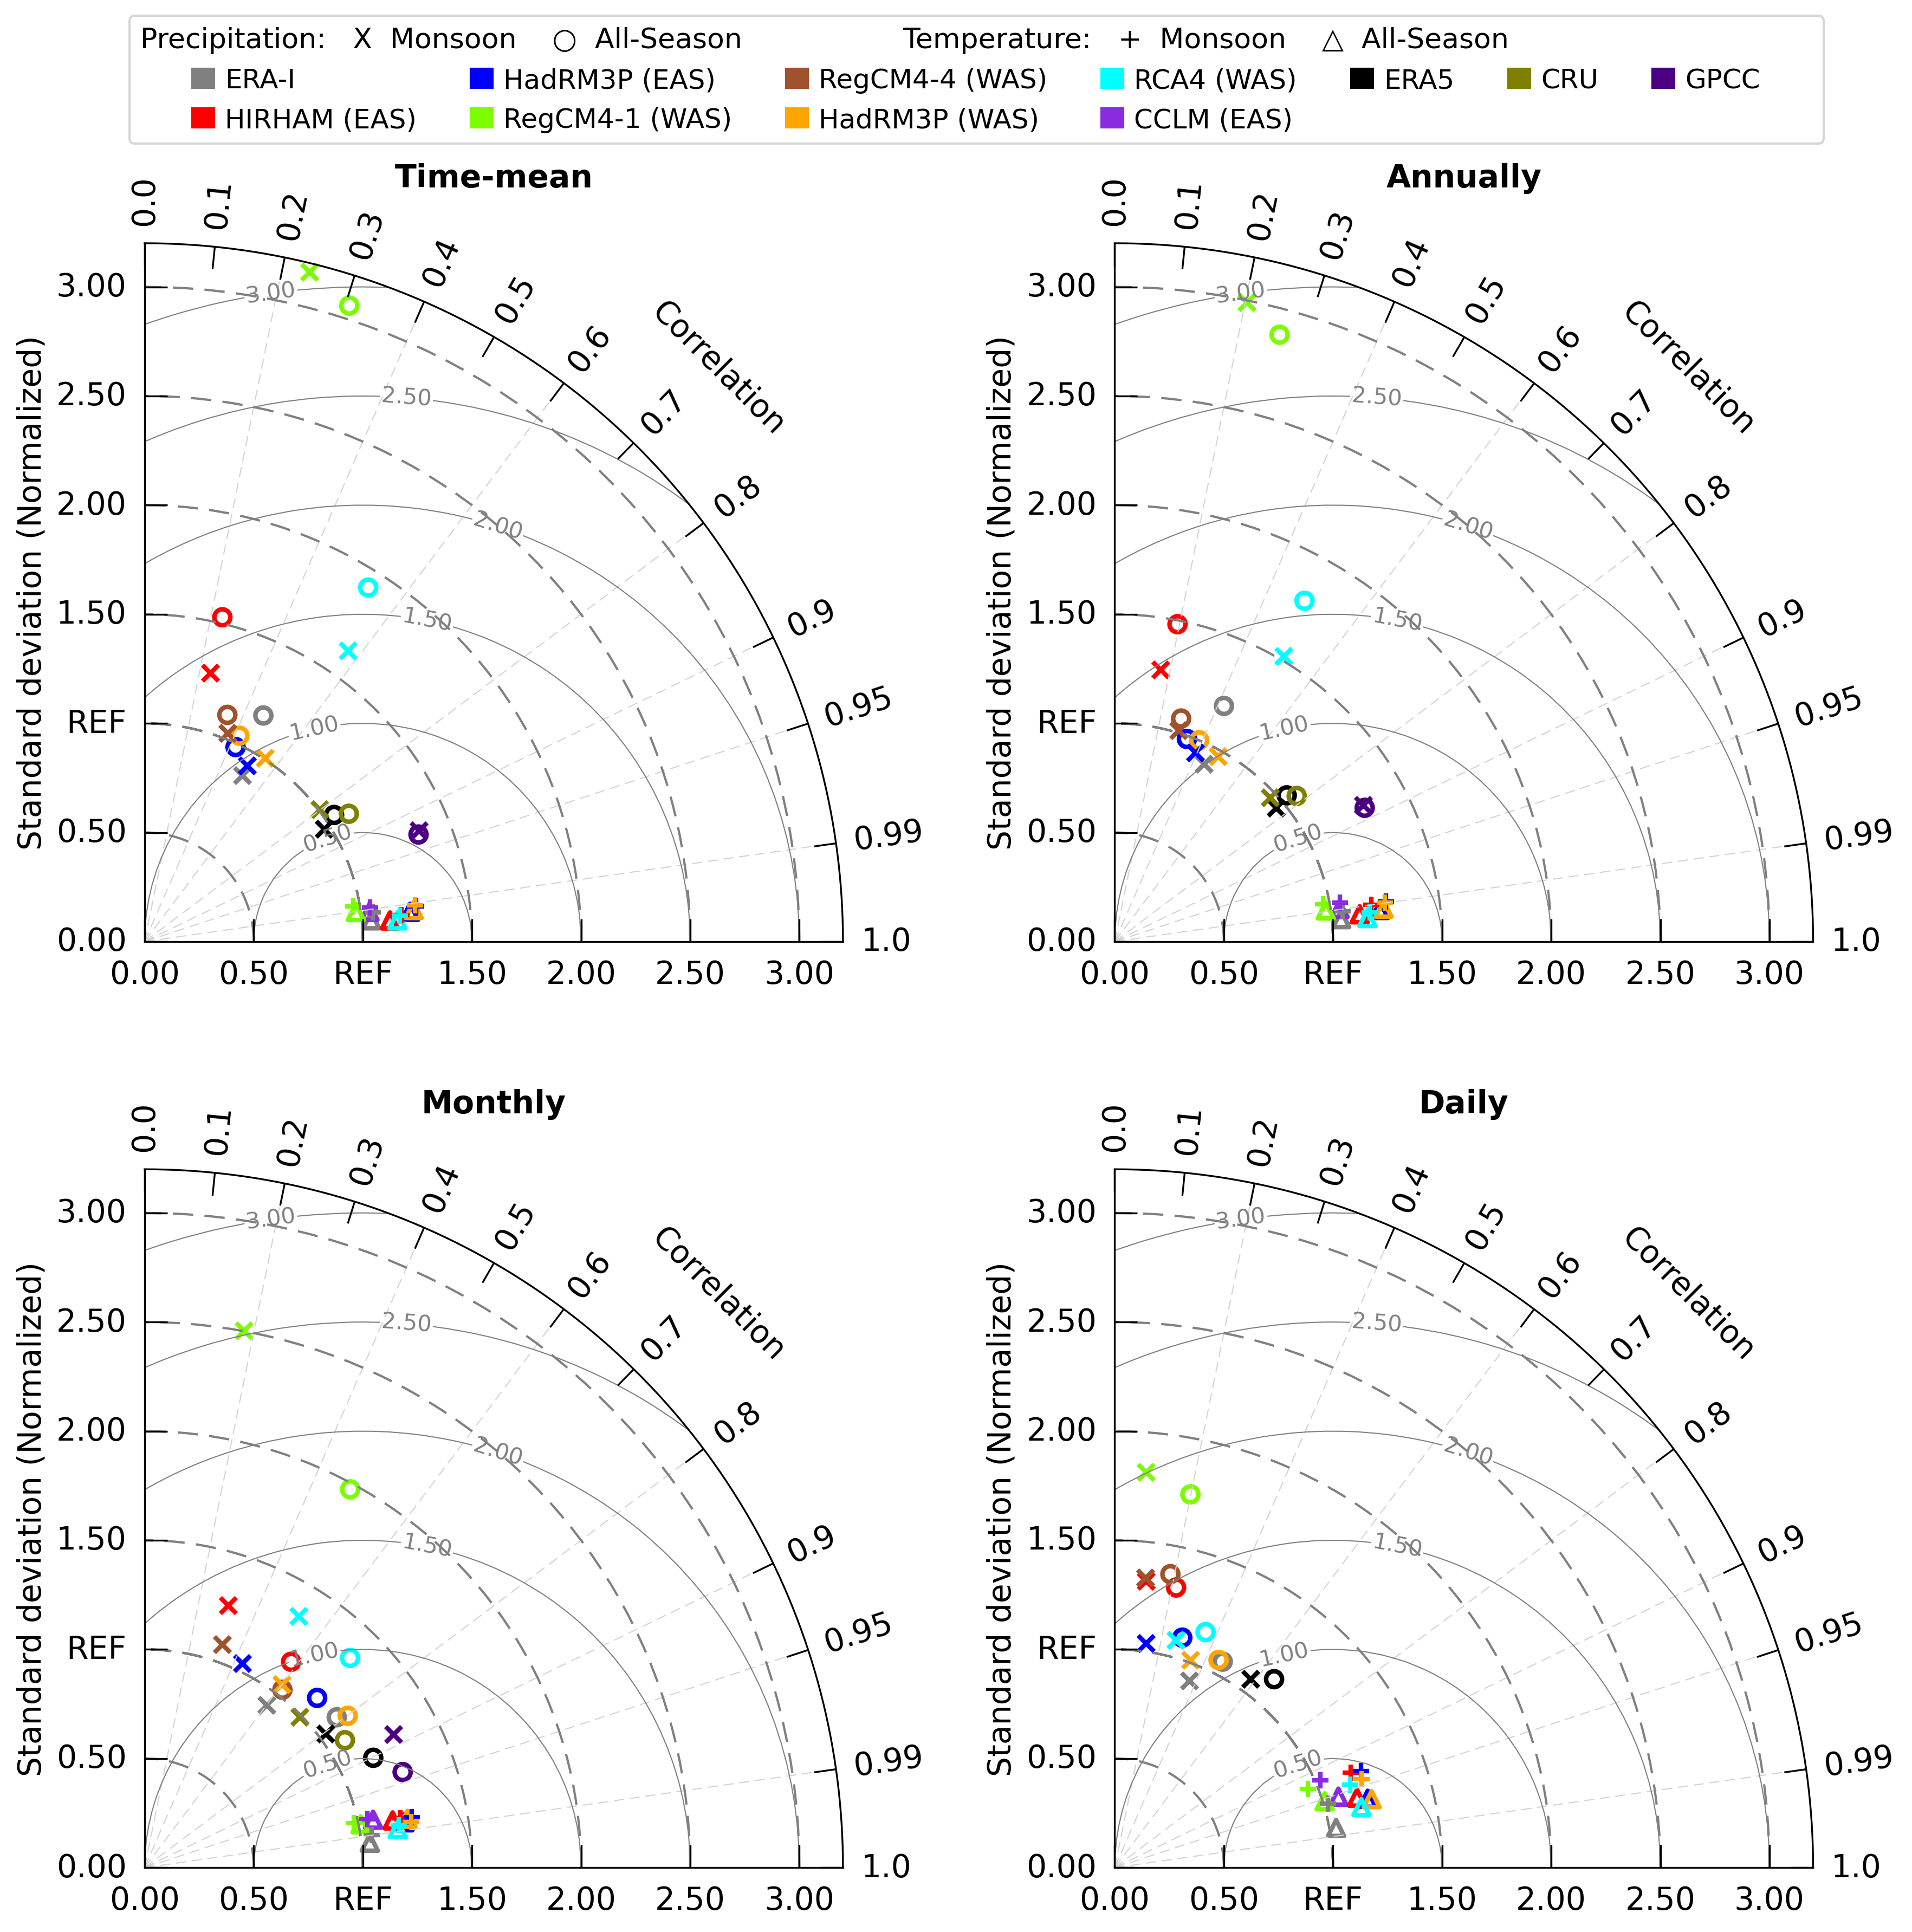

In [ ]:
# Taylor Diagram for Precipitation & Temperature (all-season & monsoon)
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(wspace=0.3, hspace=0.3, left=0.07, right=0.95, bottom=0.04)

colors_prec = ["grey", "red", "blue", "lawngreen", "sienna", "orange", "cyan", "black", "olive", "indigo"]
colors_temp = ["grey", "blueviolet", "red", "blue", "lawngreen", "orange", "cyan"]

for i in range(4):
    # Create taylor diagram
    taylor = gv.TaylorDiagram(fig=fig, rect=221 + i, label='REF', std_range=(0., 3.2), std_level=std_list)
    
    taylor.add_corr_grid(np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
        
    # Add constant centered RMS difference contours.
    RMS_contours = taylor.add_contours(levels=np.arange(0, 3.1, 0.5),
                 colors='grey',
                 linewidths=0.5)
    plt.clabel(RMS_contours, inline=1, fontsize=10, fmt='%.2f')
    
    # Add radial gridlines to the standard deviation axis specified by array.
    taylor.add_std_grid(std_list, 
             color='grey', linestyle=(0, (9, 5)), linewidth=1)

  
    # Add models to Taylor diagram
    for j in range(10):
        taylor.add_model_set( [a_sdev[i,j]],
                            [a_ccorr[i,j]],
                            annotate_on=False,
                            color=colors_prec[j],
                            marker='o',
                            facecolors='none',
                            linewidths=2,
                            s=50
                            )
       
    for j in range(10):
            taylor.add_model_set( [b_sdev[i,j]],
                            [b_ccorr[i,j]],
                            annotate_on=False,
                            color=colors_prec[j],
                            marker='x',
                            #facecolors='none',
                            linewidths=2,
                            s=50
                            )
    
    # Add models to Taylor diagram
    for j in range(7):
        taylor.add_model_set( [c_sdev[i,j]],
                            [c_ccorr[i,j]],
                            annotate_on=False,
                            color=colors_temp[j],
                            marker='^',
                            facecolors='none',
                            linewidths=2,
                            s=50
                            )
         
    for j in range(7):
            taylor.add_model_set( [d_sdev[i,j]],
                            [d_ccorr[i,j]],
                            annotate_on=False,
                            color=colors_temp[j],
                            marker='+',
                            #facecolors='none',
                            linewidths=2,
                            s=50
                            )
    
    # Set fontsize and pad
    taylor.set_fontsizes_and_pad(14, 14, 4)
    # Add title
    taylor.add_title(maintitles[i], 14, y_loc=1.05, fontweight='bold')
    
plt.legend(
    title='Precipitation:   X  Monsoon    \u25CB  All-Season                  Temperature:   +  Monsoon    \u25B3  All-Season                                  ', 
    bbox_to_anchor=(.95, 1.0), #bbox_to_anchor=(1, 0.97)
    bbox_transform=plt.gcf().transFigure,
    handlelength=0.8, handletextpad=0.4,
    title_fontsize=12.5,
    fontsize=12.,
    ncol=7, #mode="expand", 
    columnspacing=2.,#,
    handles=[legHande0, legHande2, legHande3, legHande4, legHande5, legHande6, legHande7, legHandel, legHande8, legHande9, legHande10])

plt.savefig('../Charts/Fig5_talorD_preci-temp02_spatial-Annual-Monthly-Daily_all-monsoon-j2o.tif', 
            dpi=300, 
            format="tiff", 
            pil_kwargs={"compression": "tiff_lzw"}
            )

In [ ]:
from PIL import Image, ImageOps

img0 = Image.open("../Charts/Fig5_talorD_preci-temp02_spatial-Annual-Monthly-Daily_all-monsoon-j2o.tif")
img1 = Image.open("../Charts/Fig5_talorD_temp02_spatial-Annual-Monthly-Daily_all-monsoon-j2o_v02.tif")
    #print(im.getbbox())
    # The crop method from the Image module takes four coordinates as input.
    # The right can also be represented as (left+width)
    # and lower can be represented as (upper+height).
(left, upper, right, lower) = (2800, 2900, 3570, 3570)
im_crop = img1.crop((left, upper, right, lower))
new_im_crop4 = ImageOps.expand(im_crop, border=4, fill=(0, 0, 0))

(left, upper, right, lower) = (1000, 2900, 1770, 3570)
im_crop = img1.crop((left, upper, right, lower))
new_im_crop3 = ImageOps.expand(im_crop, border=4, fill=(0, 0, 0))

(left, upper, right, lower) = (2800, 1100, 3570, 1870)
im_crop = img1.crop((left, upper, right, lower))
new_im_crop2 = ImageOps.expand(im_crop, border=4, fill=(0, 0, 0))

(left, upper, right, lower) = (1000, 1100, 1770, 1870)
im_crop = img1.crop((left, upper, right, lower))
new_im_crop1 = ImageOps.expand(im_crop, border=4, fill=(0, 0, 0))

img0.paste(new_im_crop4, (2800,2900)) 
img0.save('../Charts/01.tif', dpi=(300, 300), format="tiff", pil_kwargs={"compression": "tiff_lzw"})
img0 = Image.open("../Charts/01.tif") 

img0.paste(new_im_crop3, (1000,2900))
img0.save('../Charts/01.tif', dpi=(300, 300), format="tiff", pil_kwargs={"compression": "tiff_lzw"})
img0 = Image.open("../Charts/01.tif") 

img0.paste(new_im_crop2, (2800,1100))
img0.save('../Charts/01.tif', dpi=(300, 300), format="tiff", pil_kwargs={"compression": "tiff_lzw"})
img0 = Image.open("../Charts/01.tif") 

img0.paste(new_im_crop1, (1000,1100))
img0.save("../Charts//Fig5_talorD_preci-temp02_spatial-Annual-Monthly-Daily_all-monsoon-j2o_v031.tif",
        dpi=(300, 300), 
        format="tiff", 
        pil_kwargs={"compression": "tiff_lzw"})

#img0.show()


In [ ]:
#import matplotlib.pyplot as plt
#import matplotlib.patches as patches
from PIL import Image, ImageDraw, ImageFont

im = Image.open('../Charts//Fig5_talorD_preci-temp02_spatial-Annual-Monthly-Daily_all-monsoon-j2o_v031.tif')
font = ImageFont.truetype("arialbd.ttf", size=60)

draw = ImageDraw.Draw(im)

draw.rectangle(((550, 1500), (850, 1800)), outline=(0, 0, 0, 255), width=2) # 1
draw.polygon([(850, 1500), (1000, 1100), (1000, 1870), (850, 1800)], fill =(250, 250, 250, 255), outline =(0, 0, 0, 255))
draw.text((25,280),"(a)",fill=(0, 0, 0, 255), font=font)

draw.rectangle(((2350, 1500), (2650, 1800)), outline=(0, 0, 0, 255), width=2) # 2
draw.polygon([(2650, 1500), (2800, 1100), (2800, 1870), (2650, 1800)], fill =(250, 250, 250, 255), outline =(0, 0, 0, 255))
draw.text((1825,280),"(b)",fill=(0, 0, 0, 255), font=font)

draw.rectangle(((550, 3210), (850, 3510)), outline=(0, 0, 0, 255), width=2) # 3
draw.polygon([(850, 3210), (1000, 2900), (1000, 3570), (850, 3510)], fill = (250, 250, 250, 255), outline =(0, 0, 0, 255))
draw.text((25,1980),"(c)",fill=(0, 0, 0, 255), font=font)

draw.rectangle(((2350, 3210), (2650, 3510)), outline=(0, 0, 0, 255), width=2) # 4
draw.polygon([(2650, 3210), (2800, 2900), (2800, 3570), (2650, 3510)], fill = (250, 250, 250, 255), outline =(0, 0, 0, 255))
draw.text((1825,1980),"(d)",fill=(0, 0, 0, 255), font=font)

im.save("../Charts/Fig5_talorD_preci-temp02_spatial-Annual-Monthly-Daily_all-monsoon-j2o_v04-21.tif", 
        dpi=(300, 300), 
        format="tiff", 
        pil_kwargs={"compression": "tiff_lzw"}) 
im.show()

In [ ]:
# This rezises an image to 7.5 by 7.5 inches

from PIL import Image

def resize_by_width_inch(input_path, output_path, target_width_inch, dpi=300):
    img = Image.open(input_path)
    orig_width, orig_height = img.size
    
    # Calculate aspect ratio
    aspect_ratio = orig_height / orig_width
    
    # Convert target width inch to pixels
    target_width_px = int(target_width_inch * dpi)
    # Scale height automatically based on the original ratio
    target_height_px = int(target_width_px * aspect_ratio)
    
    # Process and save
    resized_img = img.resize((target_width_px, target_height_px), Image.Resampling.LANCZOS)
    resized_img.save(output_path, dpi=(dpi, dpi))
    
    # Calculate final output height in inches for tracking
    target_height_inch = target_height_px / dpi
    print(f"Proportionally scaled to {target_width_inch}x{target_height_inch:.2f} inches.")

# Example: Force width to 7.5 inches, let height scale naturally
resize_by_width_inch("../Charts/Fig4_talorD_preci-temp02_spatial-Annual-Monthly-Daily_all-monsoon-j2o_v04-21.tif", "../Charts/Fig4.tif", target_width_inch=7.5, dpi=300)